# Computer Vision SS 2021
## Exercise Sheet 1: Imaging
### Erhardt Barth / Philipp Gruening / Christoph Linse / Manuel Laufer
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{barth, gruening, linse, laufer} @inb.uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Max-Ole von Waldow
2. Hannah Lück
3. Alissa Kovalenko
4. Hauke Budig
5.


In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [ ]:
import cv2 # open cv
import matplotlib.pyplot as plt # plotting tools
import numpy as np # matrix, array operations

from os.path import join # combine different items to a path
from os import getcwd, listdir # shows the current directory, lists items in a directory

# show plots when running cell
%matplotlib inline

## Exercise 1.1
### Loading and displaying images in Python
Download the image `clown.png` from the website of the tutorial. Load
the image in Python via opencv (`cv2.imread`). By default the image is loaded as BGR (blue, green, red), convert the image to gray with `cv2.cvtColor`.
Display the image `plt.imshow`, use the colormap `gray`.

current folder: /content/cs4250


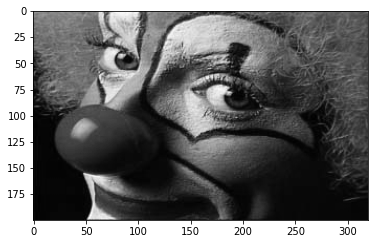

In [ ]:
# TODO: define image path
path = "./data/exercise_1/clown.png"
print("current folder:", os.getcwd())
# TODO: read image
img_color = cv2.imread(path)
# TODO: convert image to grayscale
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY )
# TODO: display image
plt.imshow(img, cmap='gray')

## Exercise 1.2
### Image gradients
Images are stored as `numpy arrays`, for further computations convert the array to range $[0, 1]$ (`astype`). Define a function `load_gray_normalized` that loads the image, converts it to grayscale and normalizes it.
Compute the image gradients $d_x$ and $d_y$ for the image from the previous assignment. Initialize a simple gradient kernel like $[-1, 0, +1]$ for $d_x$ (`np.zeros`, `np.array`) and filter the image with it (`cv2.filter2D`). Visualize the results using `plt.imshow`. To this end, display the resulting images of both derivatives along `x` and `y` in a single figure (`plt.subplots`).

What do you need to take care of, to be able to visually **compare** the results?
Hint: the problem is related to the range of the pixel values in the two
gradient images. Name the problem and propose a solution to it by using the options of the `plt.imshow`
function.

In [ ]:
def load_gray_normalized(image_path):
  # load img
  img_color = cv2.imread(image_path)
  # convert image to grayscale
  img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY )
  # normalize
  print(img_gray.dtype)
  img_float = img_gray.astype('float64')
  print("maximum value:", np.amax(img_float))
  print(img_float.dtype)
  img_norm = img_float/255.0
  return img_norm

uint8
maximum value: 248.0
float64
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]
-2.0039215686274505
2.1725490196078434
0.0
0.9725490196078431


Text(0.5, 1.0, 'dy')

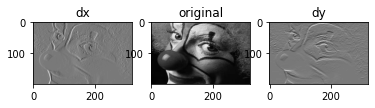

In [ ]:
# TODO: load image
img = load_gray_normalized(path)

# TODO: define kernels
kernelx = np.array([[-1, 0, +1],[-1, 0, +1],[-1, 0, +1]])
kernely = np.transpose(kernelx)
print(kernelx)
print(kernely)

# TODO: filter images
img_dx = cv2.filter2D(img, -1, kernelx)
img_dy = cv2.filter2D(img, -1, kernely)

# TODO: display images
f, (ax1, ax2, ax3) = plt.subplots(1, 3)
min_y = np.amin(img_dy)
max_y = np.amax(img_dy)
min_x = np.amin(img)
max_x = np.amax(img)
print(min_y)
print(max_y)
print(min_x)
print(max_x)

ax1.imshow(img_dx, cmap='gray', vmin=min(min_x, min_y), vmax=max(max_x, max_y))
ax1.set_title("dx")

ax2.imshow(img, cmap='gray')
ax2.set_title("original")

ax3.imshow(img_dy, cmap='gray', vmin=min(min_x, min_y), vmax=max(max_x, max_y))
ax3.set_title("dy")

# Problem:  Image looks mostly gray. Convolution has changed the range of the pixel values of the images.
# Solution: vmin & vmax change the mapping of the pixel value to the shown color value. This improves the contrast.

## Exercise 1.3
### Point operations
Download from the website the images `ueb131.png` and `ueb132.png`,
then load and display them.  
Both images illustrate two commonly encountered problems in photography.
Underexposed (overexposed) images are darker (brighter) than they should be,
because they have been exposed to too little (too much) light.

Compute and display the histograms (`plt.hist`,`np.flatten`) of the images in range $[0,1]$. Write a function `display_with_hist` that creates two subplots, showing the image and the respective histogram.

Can you identify the exposure problems in the histograms?
Hint: look at how the pixel intensities are distributed.

These defects can be corrected by remapping the pixel values to achieve a
more evenly distributed range of pixel intensities.
This can either be done by using histogram equalization (`cv2.equalizeHist`) or by using the logarithmic and power functions.

To use `cv2.equalizeHist`, the images need to be casted to uint8 in $[0,255]$. Write a function `normalized_to_uint8` to do this.

Apply the logarithmic and power to improve the two images. Experiment with different bases for the logarithm and power. To get a better feeling for the problem, plot the functions $x^2$ in $[0,1]$ and $log(x)$ in $[1,255]$ (why not $[0, 255]$?, `np.linspace, np.log, plt.plot`). **Where do the functions change quickly, where do they change slowly? How can you use this knowledge to improve the images?**

In [ ]:
def display_with_hist(image):
  # hist of img
  #histogram = plt.hist(image)

  # create two subplots: image and respective histogram
  f, (ax1, ax2) = plt.subplots(1, 2)
  ax1.imshow(image, cmap='gray')
  ax1.set_title("original")

  ax2.hist(image.flatten())
  ax2.set_title("histogram")

In [ ]:
def normalized_to_uint8(image):
  # UNnormalize values. [0,1] -> [0,255]
  img = image*255.0
  return img.astype('uint8')

uint8
maximum value: 255.0
float64
uint8
maximum value: 255.0
float64


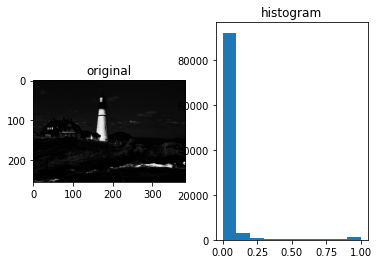

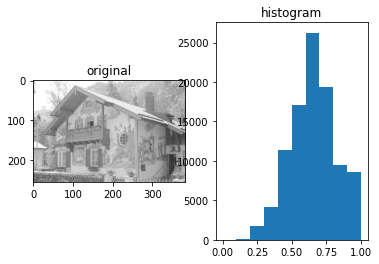

In [ ]:
# TODO: load images
img_131 = load_gray_normalized("./data/exercise_1/ueb131.png")
img_132 = load_gray_normalized("./data/exercise_1/ueb132.png")

# TODO: display images with histograms
display_with_hist(img_131)  # exposure problem: underexposed, Pixel values too dark
display_with_hist(img_132)  # exposure problem: overexposed, Pixel values too light

img_131_eq [[ 96  96  96 ...  96  87  96]
 [119  96 119 ...  96  87  96]
 [119  96 119 ...  96  96 119]
 ...
 [234 246 242 ...  26  26  47]
 [224 228 215 ...  47  47  26]
 [ 26  26  47 ...   0   0   0]]


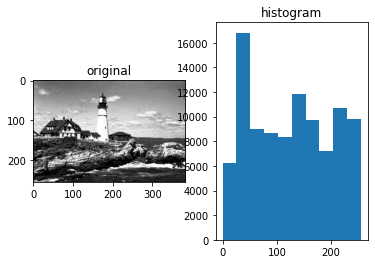

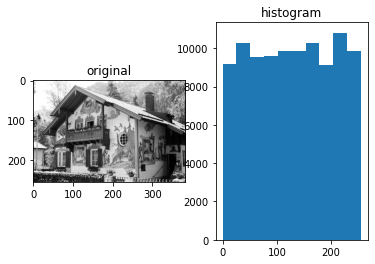

In [ ]:
# TODO: convert images to uint8
img_131_255 = normalized_to_uint8(img_131)
img_132_255 = normalized_to_uint8(img_132)

# TODO: equalize histogram and display
img_131_eq = cv2.equalizeHist(img_131_255)
print("img_131_eq", img_131_eq)
img_132_eq = cv2.equalizeHist(img_132_255)
# show both
display_with_hist(img_131_eq)
display_with_hist(img_132_eq)


Text(0.5, 1.0, 'x^6')

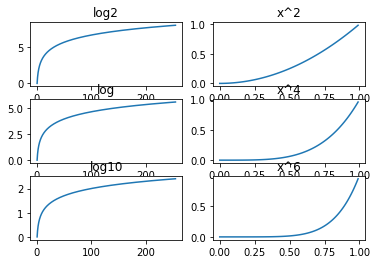

In [ ]:
f, ax = plt.subplots(3, 2)

# TODO: display logarithmic function
xrnge1 = np.arange(1,255,0.01)  # no log of 0 defined!
ax[0][0].plot(xrnge1, np.log2(xrnge1)) # changes quick at low values, slow at large values
ax[0][0].set_title("log2")
ax[1][0].plot(xrnge1, np.log(xrnge1)) # changes quick at low values, slow at large values
ax[1][0].set_title("log")
ax[2][0].plot(xrnge1, np.log10(xrnge1)) # changes quick at low values, slow at large values
ax[2][0].set_title("log10")

# TODO: display quadratic function
xrnge2 = np.arange(0,1,0.01)
ax[0][1].plot(xrnge2, np.power(xrnge2, 2)) # changes quick at large values, slow at low values
ax[0][1].set_title("x^2")
ax[1][1].plot(xrnge2, np.power(xrnge2, 4)) # changes quick at large values, slow at low values
ax[1][1].set_title("x^4")
ax[2][1].plot(xrnge2, np.power(xrnge2, 6)) # changes quick at large values, slow at low values
ax[2][1].set_title("x^6")


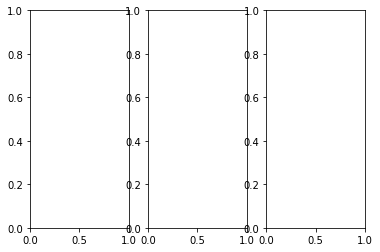

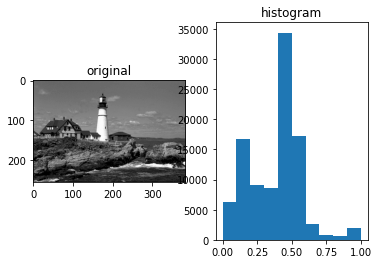

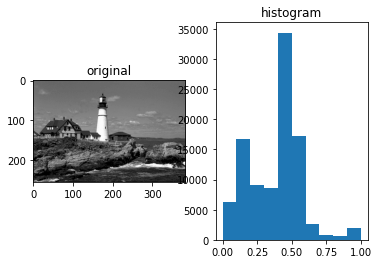

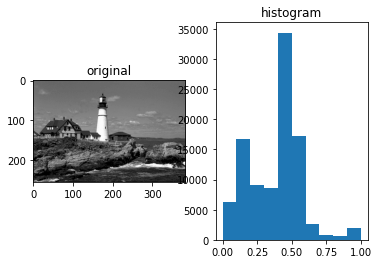

In [ ]:
# TODO: transform and display ueb131.png
# use log to lighten darks
# remove zeroes
img_131_noZeros = np.copy(img_131)
img_131_noZeros *= 255.0
img_131_noZeros += 1

img_131_log2 = np.log2(img_131_noZeros) / np.log2(256)
img_131_log = np.log(img_131_noZeros) / np.log(256)
img_131_log10 = np.log10(img_131_noZeros) / np.log10(256)

f, ax = plt.subplots(1, 3)

"""ax[0].imshow(np.log2(img_131_noZeros).astype('uint8'),  cmap='gray')
ax[1].imshow(np.log(img_131_noZeros).astype('uint8'),   cmap='gray')
ax[2].imshow(np.log10(img_131_noZeros).astype('uint8'), cmap='gray')"""

#display_with_hist(np.log2(img_131_noZeros).astype('uint8'))
display_with_hist(img_131_log2)
display_with_hist(img_131_log)
display_with_hist(img_131_log10)
#display_with_hist(np.log10(img_131_noZeros).astype('uint8'))

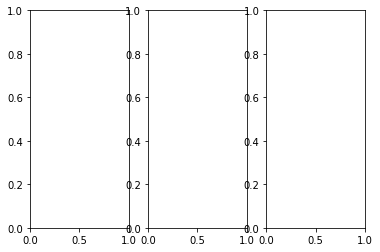

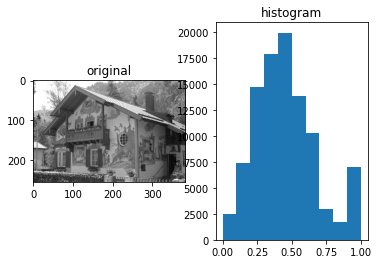

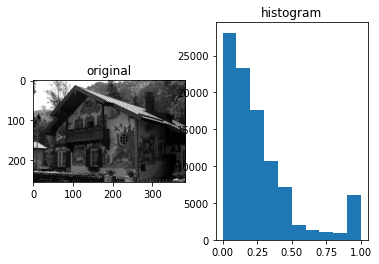

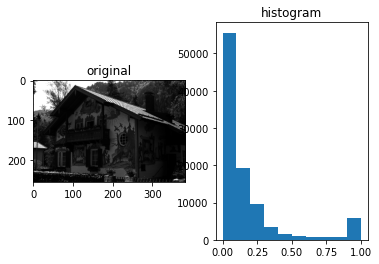

In [ ]:
# TODO: transform and display ueb132.png
# use square to darken bright values
f, ax = plt.subplots(1, 3)

"""ax[0].imshow(np.power(img_132, 2), cmap='gray')
ax[1].imshow(np.power(img_132, 4), cmap='gray')
ax[2].imshow(np.power(img_132, 6), cmap='gray')"""


display_with_hist(np.power(img_132, 2))
display_with_hist(np.power(img_132, 4))
display_with_hist(np.power(img_132, 6))